In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

In [6]:
# 1) Cargar datos
movies = pd.read_csv("movies.csv")

In [7]:
# 2) Construir texto por película
for col in ["title", "genres", "tags", "overview"]:
    if col not in movies.columns:
        movies[col] = ""

movies["text"] = (
    movies["title"].fillna("") + " " +
    movies["genres"].fillna("") + " " +
    movies["tags"].fillna("") + " " +
    movies["overview"].fillna("")
).str.lower()

In [8]:
# 3) TF-IDF embeddings de películas
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english"   # si tu texto está en español: pon None
)
X_movie = vectorizer.fit_transform(movies["text"])  # (n_movies, n_terms) sparse
X_movie = normalize(X_movie, norm="l2")

In [11]:
# 4) K-means sobre películas
K = 3
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=20, random_state=42)
labels = kmeans.fit_predict(X_movie)

movies["cluster"] = labels
print("Películas por cluster:\n", movies["cluster"].value_counts().sort_index())

Películas por cluster:
 cluster
0     65
1    159
2     26
Name: count, dtype: int64



--- Top términos por cluster ---
Cluster 0: adventure, rival, prophecy, explosion, kingdom, artifact, dragon, quest
Cluster 1: detective, awkward, true, stand, whispers, family, drama, prank
Cluster 2: alien, alien signal, signal, android, loop, time loop, station, space station


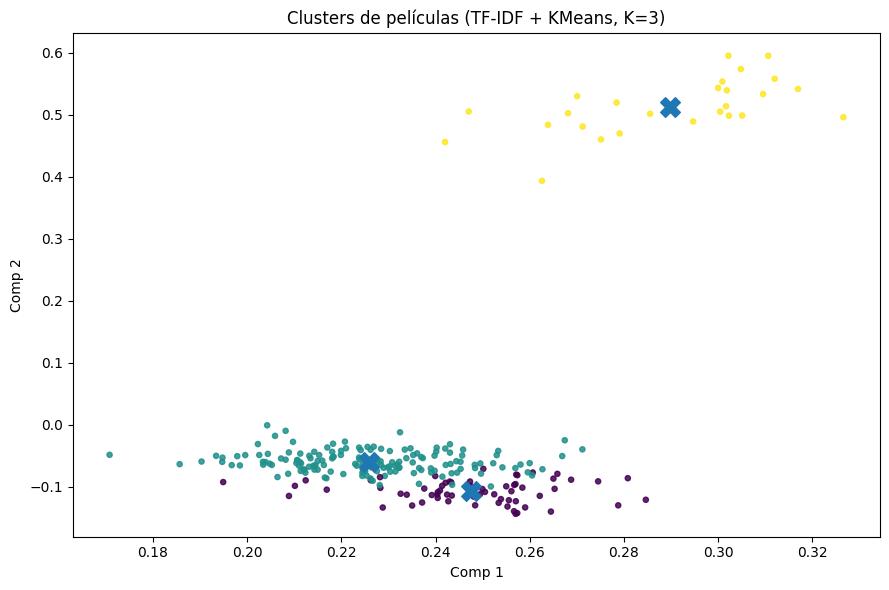

In [12]:
# 5) (Opcional) Mostrar top términos por cluster (interpretación)
vocab = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_
TOP_TERMS = 8

print("\n--- Top términos por cluster ---")
for c in range(K):
    top_idx = np.argsort(centroids[c])[-TOP_TERMS:][::-1]
    top_terms = [vocab[i] for i in top_idx]
    print(f"Cluster {c}: {', '.join(top_terms)}")

# 6) Plot 2D con TruncatedSVD (bien para sparse)
svd = TruncatedSVD(n_components=2, random_state=42)
X2 = svd.fit_transform(X_movie)
C2 = svd.transform(kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
plt.scatter(X2[:, 0], X2[:, 1], c=labels, s=14, alpha=0.85)
plt.scatter(C2[:, 0], C2[:, 1], marker="X", s=200)
plt.title(f"Clusters de películas (TF-IDF + KMeans, K={K})")
plt.xlabel("Comp 1")
plt.ylabel("Comp 2")
plt.tight_layout()
plt.show()
